
# OE-only Conversation vs Non-Conversation Differentiator

This notebook builds a focused OpenEarable-only experiment:

**Task:** conversation vs non-conversation  
**Positive class:** `conversation`  
**Negative class:** `non_conversation = co_building + co_merging`  
**Sensors:** OpenEarable developed features only, including `oe__...` and `mag__...` columns  
**Evaluation:** Leave-One-Group-Out (LOGO), so each group is held out once  

It runs three comparisons:

1. **Classical, no elapsed**: OE features only  
2. **Classical, with elapsed**: OE features + causal `elapsed_min`  
3. **Deep learning, no elapsed**: OE sequence models without any time feature

The purpose is to show whether OpenEarable can provide value on a task where head movement, head orientation, and conversational behaviour should be informative.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:

# ================================================================
# SETUP
# ================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu



## Configuration

The notebook uses the existing advanced merged 10-second dataset from the previous pipeline. This dataset already combines the developed OE, OptiTrack and Xsens features. In this notebook we filter it to **OE-only** columns.


In [7]:

# ================================================================
# CONFIG
# ================================================================

# Existing advanced merged dataset created in the previous notebook.
ADVANCED_DATA_PATH = (
    "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/"
    "activity3_advanced_merged_10s_features.csv"
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION"
os.makedirs(OUT_DIR, exist_ok=True)

CLASSICAL_SUMMARY_PATH = f"{OUT_DIR}/oe_conv_nonconv_classical_summary.csv"
CLASSICAL_PRED_PATH = f"{OUT_DIR}/oe_conv_nonconv_classical_predictions.csv"
CLASSICAL_BEST_PATH = f"{OUT_DIR}/oe_conv_nonconv_classical_best_per_condition.csv"
DL_SUMMARY_PATH = f"{OUT_DIR}/oe_conv_nonconv_dl_no_elapsed_summary.csv"
DL_FOLD_PATH = f"{OUT_DIR}/oe_conv_nonconv_dl_no_elapsed_fold_metrics.csv"
DL_PRED_PATH = f"{OUT_DIR}/oe_conv_nonconv_dl_no_elapsed_predictions.csv"

LABEL_COL = "recognition_label"
GROUP_COL = "group"
START_COL = "window_start"
END_COL = "window_end"

POS_LABEL = "conversation"
NEG_LABEL = "non_conversation"
TARGET_COL = "conv_binary_label"

# Classical settings
K_CLASSICAL = [40, 80, 120, 200, "all"]
TIME_CONDITIONS = ["no_elapsed", "with_elapsed"]

# DL settings, 10-second windows: 3=30s, 6=60s, 9=90s
SEEDS = [42]
SEQ_LENS = [3, 6, 9]
K_DL = [80, 120, 200]
MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 64

# Set to a small number like 4 for a quick test, then None for full run.
STOP_AFTER_N_DL_RUNS = None


In [ ]:

# Optional for Google Colab. Uncomment if needed.
# from google.colab import drive
# drive.mount('/content/drive')



## Load data and create the new binary label

We convert the original 3-class recognition labels into:

- `conversation` = positive class
- `non_conversation` = `co_building` + `co_merging`


In [8]:
import numpy as np
import pandas as pd

# ================================================================
# LOAD DATA
# ================================================================

if not os.path.exists(ADVANCED_DATA_PATH):
    raise FileNotFoundError("Could not find advanced dataset:" + ADVANCED_DATA_PATH + "\n\nRun the advanced merged dataset creation cell first."
    )

df = pd.read_csv(ADVANCED_DATA_PATH)

print("=" * 100)
print("LOADED ADVANCED 10s DATASET")
print("=" * 100)
print("Path:", ADVANCED_DATA_PATH)
print("Shape:", df.shape)

# Keep the three core recognition classes only.
CORE = ["co_building", "co_merging", "conversation"]
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
df = df[df[LABEL_COL].isin(CORE)].copy().reset_index(drop=True)

# Binary label: conversation vs non-conversation.
df[TARGET_COL] = np.where(df[LABEL_COL] == "conversation", POS_LABEL, NEG_LABEL)

display(df[LABEL_COL].value_counts())
display(df[TARGET_COL].value_counts())

print("\nGroup x binary label counts:")
display(pd.crosstab(df[GROUP_COL], df[TARGET_COL]))

# Causal elapsed time: minutes since each group's first window midpoint.
# This does not use session end time.
df["window_mid"] = (pd.to_numeric(df[START_COL], errors="coerce") + pd.to_numeric(df[END_COL], errors="coerce")) / 2.0
df["elapsed_min"] = (df["window_mid"] - df.groupby(GROUP_COL)["window_mid"].transform("min")) / 60.0

print("\nElapsed time check:")
display(df.groupby(GROUP_COL)["elapsed_min"].agg(["min", "max", "mean"]).round(2))

# Check for NaN values in elapsed_min after calculation
nan_elapsed_min_count = df['elapsed_min'].isnull().sum()
if nan_elapsed_min_count > 0:
    print(f"\nWARNING: Found {nan_elapsed_min_count} NaN values in 'elapsed_min' column.")
    print("These typically occur if 'window_start' or 'window_end' were non-numeric or missing for an entire group.")
    print("Consider inspecting rows with NaN 'elapsed_min' if this is unexpected.")

LOADED ADVANCED 10s DATASET
Path: /content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/activity3_advanced_merged_10s_features.csv
Shape: (992, 1543)


,count
recognition_label,
co_building,548
conversation,311
co_merging,133


,count
conv_binary_label,
non_conversation,681
conversation,311



Group x binary label counts:


conv_binary_label,conversation,non_conversation
group,,
1,57,52
2,26,80
3,42,47
5,13,117
6,29,53
7,25,137
8,49,58
9,54,118
10,16,19



Elapsed time check:


,min,max,mean
group,,,
1,0.0,30.17,17.22
2,0.0,40.33,29.21
3,0.0,43.33,27.10
5,0.0,52.67,40.03
6,0.0,20.33,11.19
7,0.0,47.83,29.39
8,0.0,37.17,21.90
9,0.0,58.33,34.72
10,0.0,10.33,5.22



## Select OE-only developed features

The advanced dataset uses prefixes such as:

- `oe__...` for OpenEarable motion/posture/synchrony features
- `mag__...` for OpenEarable magnetometer features
- sometimes `oebest__...` if the features came from an earlier merged representation

This cell keeps only OE-related features and explicitly removes labels, IDs, time metadata, OptiTrack, and Xsens.


In [9]:

# ================================================================
# OE FEATURE SELECTION HELPERS
# ================================================================

def unique_feats(feats):
    return list(dict.fromkeys(feats))


def is_oe_feature(c):
    c = str(c)
    return (
        c.startswith("oe__")
        or c.startswith("oe_")
        or c.startswith("mag__")
        or c.startswith("mag_")
        or c.startswith("oebest__")
    )


def clean_feature_list(dataframe, feats, include_elapsed=False):
    bad_cols = {
        LABEL_COL,
        TARGET_COL,
        GROUP_COL,
        START_COL,
        END_COL,
        "window_mid",
        "label",
        "target",
        "class",
        "activity",
        "general_class",
        "binary_label",
        "pred",
        "prediction",
        "correct",
    }

    cleaned = []

    for f in feats:
        if f not in dataframe.columns:
            continue
        if f in bad_cols:
            continue
        if f == "elapsed_min" and not include_elapsed:
            continue
        if "elapsed" in str(f).lower() and not include_elapsed:
            continue
        if "recognition_label" in str(f).lower():
            continue
        if dataframe[f].dtype == "object":
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values
        if np.isfinite(x).sum() < 20:
            continue
        if np.nanstd(x) < 1e-12:
            continue
        cleaned.append(f)

    return unique_feats(cleaned)


oe_features = clean_feature_list(df, [c for c in df.columns if is_oe_feature(c)], include_elapsed=False)
oe_features_elapsed = unique_feats(oe_features + ["elapsed_min"])

oe_features_elapsed = clean_feature_list(df, oe_features_elapsed, include_elapsed=True)

print("OE-only usable features, no elapsed:", len(oe_features))
print("OE-only usable features, with elapsed:", len(oe_features_elapsed))

print("\nFirst 30 OE features:")
print(oe_features[:30])

if len(oe_features) == 0:
    raise ValueError("No OE features found. Check column prefixes in the advanced dataset.")


OE-only usable features, no elapsed: 305
OE-only usable features, with elapsed: 306

First 30 OE features:
['oe__ear_head_turn_event_rate', 'oe__oe_acc_energy_mean', 'oe__oe_acc_energy_std', 'oe__oe_acc_energy_min', 'oe__oe_acc_energy_max', 'oe__oe_acc_energy_range', 'oe__oe_acc_energy_std_mean', 'oe__oe_acc_energy_std_std', 'oe__oe_acc_energy_std_min', 'oe__oe_acc_energy_std_max', 'oe__oe_acc_energy_std_range', 'oe__oe_acc_energy_iqr_mean', 'oe__oe_acc_energy_iqr_std', 'oe__oe_acc_energy_iqr_min', 'oe__oe_acc_energy_iqr_max', 'oe__oe_acc_energy_iqr_range', 'oe__oe_acc_energy_range_mean', 'oe__oe_acc_energy_range_std', 'oe__oe_acc_energy_range_min', 'oe__oe_acc_energy_range_max', 'oe__oe_acc_energy_range_range', 'oe__oe_acc_energy_maddiff_mean', 'oe__oe_acc_energy_maddiff_std', 'oe__oe_acc_energy_maddiff_min', 'oe__oe_acc_energy_maddiff_max', 'oe__oe_acc_energy_maddiff_range', 'oe__oe_acc_entropy_mean', 'oe__oe_acc_entropy_std', 'oe__oe_acc_entropy_min', 'oe__oe_acc_entropy_max']



# Part 1 — Classical models

This part compares OE-only models with and without causal elapsed time.

Evaluation is LOGO: each group is held out once.


In [10]:

# ================================================================
# CLASSICAL MODEL HELPERS
# ================================================================

classical_models = {
    "logreg_C1": LogisticRegression(
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42,
    ),
    "linearSVC_C1": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42,
        max_iter=5000,
    ),
    "rbfSVC_C1_gscale": SVC(
        C=1.0,
        gamma="scale",
        kernel="rbf",
        class_weight="balanced",
        random_state=42,
    ),
    "rf_leaf2": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "extraTrees_leaf1": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}


def make_pipeline_for_model(model, k, n_features):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]

    if k != "all" and n_features > int(k):
        steps.append(("select", SelectKBest(f_classif, k=int(k))))

    steps.append(("model", model))
    return make_pipeline(*[s[1] for s in steps])


def score_binary(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    bal = balanced_accuracy_score(y_true, y_pred)

    labels = [POS_LABEL, NEG_LABEL]
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "macro_f1": macro,
        "balanced_accuracy": bal,
        "precision_conversation": pr[0],
        "recall_conversation": rc[0],
        "f1_conversation": f1[0],
        "support_conversation": sup[0],
        "precision_non_conversation": pr[1],
        "recall_non_conversation": rc[1],
        "f1_non_conversation": f1[1],
        "support_non_conversation": sup[1],
    }


def run_classical_condition(feature_list, time_condition, model_name, model, k):
    X_df = df[feature_list].apply(pd.to_numeric, errors="coerce")
    X = X_df.values
    y = df[TARGET_COL].values
    groups = df[GROUP_COL].values

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []
    pred_rows = []

    for fold, (tr, te) in enumerate(logo.split(X, y, groups), start=1):
        clf = make_pipeline_for_model(model, k, X.shape[1])
        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        y_true_all.extend(y[te])
        y_pred_all.extend(pred)

        for idx, p in zip(te, pred):
            pred_rows.append({
                "fold": fold,
                "test_group": groups[idx],
                "row_index": int(idx),
                "window_start": df.iloc[idx][START_COL],
                "window_end": df.iloc[idx][END_COL],
                "true": y[idx],
                "pred": p,
                "correct": int(y[idx] == p),
                "time_condition": time_condition,
                "model": model_name,
                "k": k,
                "n_features": len(feature_list),
            })

    metrics = score_binary(np.array(y_true_all), np.array(y_pred_all))
    metrics.update({
        "time_condition": time_condition,
        "model": model_name,
        "k": k,
        "n_features": len(feature_list),
    })

    return metrics, pd.DataFrame(pred_rows)


In [11]:

# ================================================================
# RUN CLASSICAL GRID
# ================================================================

summary_rows = []
pred_dfs = []

for time_condition in TIME_CONDITIONS:
    feats = oe_features if time_condition == "no_elapsed" else oe_features_elapsed

    for model_name, model in classical_models.items():
        for k in K_CLASSICAL:
            if k != "all" and int(k) > len(feats):
                continue

            print(f"Running classical | {time_condition} | {model_name} | k={k} | n_features={len(feats)}")

            metrics, pred_df = run_classical_condition(
                feature_list=feats,
                time_condition=time_condition,
                model_name=model_name,
                model=model,
                k=k,
            )

            summary_rows.append(metrics)
            pred_dfs.append(pred_df)

classical_summary = pd.DataFrame(summary_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

classical_preds = pd.concat(pred_dfs, ignore_index=True)

classical_summary.to_csv(CLASSICAL_SUMMARY_PATH, index=False)
classical_preds.to_csv(CLASSICAL_PRED_PATH, index=False)

best_per_condition = (
    classical_summary
    .sort_values(["time_condition", "macro_f1", "accuracy"], ascending=[True, False, False])
    .groupby("time_condition", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_per_condition.to_csv(CLASSICAL_BEST_PATH, index=False)

print("\nTop classical results:")
display(classical_summary.head(20).round(4))

print("\nBest classical result per time condition:")
display(best_per_condition.round(4))

print("\nSaved:")
print(CLASSICAL_SUMMARY_PATH)
print(CLASSICAL_PRED_PATH)
print(CLASSICAL_BEST_PATH)


Running classical | no_elapsed | logreg_C1 | k=40 | n_features=305
Running classical | no_elapsed | logreg_C1 | k=80 | n_features=305
Running classical | no_elapsed | logreg_C1 | k=120 | n_features=305
Running classical | no_elapsed | logreg_C1 | k=200 | n_features=305
Running classical | no_elapsed | logreg_C1 | k=all | n_features=305
Running classical | no_elapsed | linearSVC_C1 | k=40 | n_features=305
Running classical | no_elapsed | linearSVC_C1 | k=80 | n_features=305
Running classical | no_elapsed | linearSVC_C1 | k=120 | n_features=305
Running classical | no_elapsed | linearSVC_C1 | k=200 | n_features=305
Running classical | no_elapsed | linearSVC_C1 | k=all | n_features=305
Running classical | no_elapsed | rbfSVC_C1_gscale | k=40 | n_features=305
Running classical | no_elapsed | rbfSVC_C1_gscale | k=80 | n_features=305
Running classical | no_elapsed | rbfSVC_C1_gscale | k=120 | n_features=305
Running classical | no_elapsed | rbfSVC_C1_gscale | k=200 | n_features=305
Running cla

,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,time_condition,model,k,n_features
0,0.8075,0.7810,0.7873,0.6786,0.7331,0.7048,311,0.8735,0.8414,0.8571,681,with_elapsed,logreg_C1,80,306
1,0.8075,0.7784,0.7811,0.6863,0.7106,0.6983,311,0.8657,0.8517,0.8586,681,with_elapsed,logreg_C1,40,306
2,0.8054,0.7772,0.7814,0.6799,0.7170,0.6980,311,0.8675,0.8458,0.8565,681,with_elapsed,logreg_C1,200,306
3,0.8024,0.7701,0.7696,0.6861,0.6817,0.6839,311,0.8551,0.8576,0.8563,681,with_elapsed,linearSVC_C1,40,306
4,0.7984,0.7697,0.7745,0.6677,0.7106,0.6885,311,0.8638,0.8385,0.8510,681,with_elapsed,logreg_C1,120,306
5,0.7974,0.7676,0.7712,0.6687,0.7010,0.6845,311,0.8604,0.8414,0.8508,681,with_elapsed,logreg_C1,all,306
6,0.7954,0.7645,0.7671,0.6677,0.6913,0.6793,311,0.8567,0.8429,0.8497,681,with_elapsed,linearSVC_C1,200,306
7,0.7883,0.7616,0.7707,0.6447,0.7235,0.6818,311,0.8663,0.8179,0.8414,681,with_elapsed,linearSVC_C1,80,306
8,0.7843,0.7548,0.7608,0.6439,0.6977,0.6698,311,0.8565,0.8238,0.8398,681,with_elapsed,rbfSVC_C1_gscale,40,306
9,0.7873,0.7536,0.7542,0.6592,0.6656,0.6624,311,0.8466,0.8429,0.8447,681,with_elapsed,linearSVC_C1,all,306



Best classical result per time condition:


,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,time_condition,model,k,n_features
0,0.7339,0.7108,0.7302,0.5586,0.7203,0.6292,311,0.8528,0.7401,0.7925,681,no_elapsed,rbfSVC_C1_gscale,all,305
1,0.8075,0.7810,0.7873,0.6786,0.7331,0.7048,311,0.8735,0.8414,0.8571,681,with_elapsed,logreg_C1,80,306



Saved:
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_classical_summary.csv
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_classical_predictions.csv
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_classical_best_per_condition.csv



# Part 2 — Deep learning, OE-only, no elapsed

This part runs sequence models using only OE features and no elapsed time.

For 10-second windows:

- `seq_len = 3` means 30 seconds of context
- `seq_len = 6` means 60 seconds of context
- `seq_len = 9` means 90 seconds of context

The target is the label of the final window in the sequence.


In [12]:

# ================================================================
# DL HELPERS
# ================================================================

class RNNClassifier(nn.Module):
    def __init__(self, input_dim, rnn_type="lstm", hidden_dim=64, num_layers=1, dropout=0.25, bidirectional=False, n_classes=2):
        super().__init__()

        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.25, n_classes=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


MODEL_CONFIGS = [
    {"model_type": "lstm", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "bilstm", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "gru", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "transformer", "d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.25, "lr": 5e-4, "weight_decay": 1e-4},
]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_model(cfg, input_dim):
    t = cfg["model_type"]
    if t == "lstm":
        return RNNClassifier(input_dim=input_dim, rnn_type="lstm", hidden_dim=cfg["hidden_dim"], num_layers=cfg["num_layers"], dropout=cfg["dropout"], bidirectional=False)
    if t == "bilstm":
        return RNNClassifier(input_dim=input_dim, rnn_type="lstm", hidden_dim=cfg["hidden_dim"], num_layers=cfg["num_layers"], dropout=cfg["dropout"], bidirectional=True)
    if t == "gru":
        return RNNClassifier(input_dim=input_dim, rnn_type="gru", hidden_dim=cfg["hidden_dim"], num_layers=cfg["num_layers"], dropout=cfg["dropout"], bidirectional=False)
    if t == "transformer":
        return TransformerClassifier(input_dim=input_dim, d_model=cfg["d_model"], nhead=cfg["nhead"], num_layers=cfg["num_layers"], dim_feedforward=cfg["dim_feedforward"], dropout=cfg["dropout"])
    raise ValueError(t)


def make_sequences(X, y, groups, starts, seq_len):
    X_seq, y_seq, g_seq, start_seq = [], [], [], []
    for g in sorted(np.unique(groups)):
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]
        if len(idx) < seq_len:
            continue
        for j in range(seq_len - 1, len(idx)):
            seq_idx = idx[j - seq_len + 1:j + 1]
            X_seq.append(X[seq_idx])
            y_seq.append(y[idx[j]])
            g_seq.append(g)
            start_seq.append(starts[idx[j]])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.int64), np.asarray(g_seq), np.asarray(start_seq)


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def choose_validation_group(train_groups):
    return sorted(list(np.unique(train_groups)))[-1]


def evaluate_predictions(y_true, y_pred):
    id_to_label = {0: POS_LABEL, 1: NEG_LABEL}
    true_lab = np.array([id_to_label[int(i)] for i in y_true])
    pred_lab = np.array([id_to_label[int(i)] for i in y_pred])
    return score_binary(true_lab, pred_lab)


In [13]:

# ================================================================
# DL TRAINING FUNCTION
# ================================================================

label_to_id = {POS_LABEL: 0, NEG_LABEL: 1}
y_all = df[TARGET_COL].map(label_to_id).astype(int).values
groups_all = df[GROUP_COL].values
starts_all = pd.to_numeric(df[START_COL], errors="coerce").values


def train_one_dl_run(seq_len, k_features, model_cfg, seed):
    set_seed(seed)

    feature_list = oe_features.copy()  # no elapsed for DL
    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []
    fold_rows = []
    pred_rows = []

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):
        test_group = groups_all[te_idx][0]
        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        # Fold-safe imputation, scaling, and feature selection.
        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(X_raw[tr_idx])
        Xval = imputer.transform(X_raw[val_idx])
        Xte = imputer.transform(X_raw[te_idx])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(int(k_features), Xtr.shape[1])
        selector = SelectKBest(f_classif, k=actual_k)
        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        X_fold = np.zeros((len(X_raw), actual_k), dtype=np.float32)
        X_fold[tr_idx] = Xtr
        X_fold[val_idx] = Xval
        X_fold[te_idx] = Xte

        Xtr_seq, ytr_seq, _, _ = make_sequences(X_fold[tr_idx], y_all[tr_idx], groups_all[tr_idx], starts_all[tr_idx], seq_len)
        Xval_seq, yval_seq, _, _ = make_sequences(X_fold[val_idx], y_all[val_idx], groups_all[val_idx], starts_all[val_idx], seq_len)
        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(X_fold[te_idx], y_all[te_idx], groups_all[te_idx], starts_all[te_idx], seq_len)

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            print(f"Skipping fold {fold}: not enough sequences")
            continue

        model = build_model(model_cfg, input_dim=actual_k).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=model_cfg["lr"], weight_decay=model_cfg["weight_decay"])
        loss_fn = nn.CrossEntropyLoss()

        train_loader = make_loader(Xtr_seq, ytr_seq, BATCH_SIZE, shuffle=True)
        val_loader = make_loader(Xval_seq, yval_seq, BATCH_SIZE, shuffle=False)
        test_loader = make_loader(Xte_seq, yte_seq, BATCH_SIZE, shuffle=False)

        best_state = None
        best_val_macro = -1
        best_epoch = 0
        patience_left = PATIENCE

        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            # validation
            model.eval()
            val_preds = []
            val_true = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    logits = model(xb.to(DEVICE))
                    pred = logits.argmax(1).cpu().numpy()
                    val_preds.extend(pred)
                    val_true.extend(yb.numpy())

            val_macro = f1_score(val_true, val_preds, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_epoch = epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_left = PATIENCE
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break

        model.load_state_dict(best_state)
        model.eval()

        fold_preds = []
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = model(xb.to(DEVICE))
                fold_preds.extend(logits.argmax(1).cpu().numpy())

        y_true_all.extend(yte_seq)
        y_pred_all.extend(fold_preds)

        fold_metrics = evaluate_predictions(np.array(yte_seq), np.array(fold_preds))
        fold_metrics.update({
            "fold": fold,
            "test_group": test_group,
            "val_group": val_group,
            "seq_len": seq_len,
            "context_seconds": seq_len * 10,
            "k_features": actual_k,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "n_test_sequences": len(yte_seq),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro,
        })
        fold_rows.append(fold_metrics)

        for yt, yp, gg, ss in zip(yte_seq, fold_preds, gte_seq, ste_seq):
            pred_rows.append({
                "fold": fold,
                "test_group": gg,
                "window_start": ss,
                "true": POS_LABEL if yt == 0 else NEG_LABEL,
                "pred": POS_LABEL if yp == 0 else NEG_LABEL,
                "correct": int(yt == yp),
                "seq_len": seq_len,
                "context_seconds": seq_len * 10,
                "k_features": actual_k,
                "model_type": model_cfg["model_type"],
                "seed": seed,
            })

    overall = evaluate_predictions(np.array(y_true_all), np.array(y_pred_all))
    overall.update({
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * 10,
        "k_features": k_features,
        "n_sequences_evaluated": len(y_true_all),
        "time_condition": "no_elapsed",
        "feature_set": "OE_ONLY",
    })

    return overall, pd.DataFrame(fold_rows), pd.DataFrame(pred_rows)


In [15]:

# ================================================================
# RUN DL GRID, OE ONLY, NO ELAPSED
# ================================================================

summary_rows = []
fold_dfs = []
pred_dfs = []

run_counter = 0
stop_now = False

total_runs = len(SEEDS) * len(SEQ_LENS) * len(K_DL) * len(MODEL_CONFIGS)
print("Total planned DL runs:", total_runs)

for seed in SEEDS:
    if stop_now: break
    for seq_len in SEQ_LENS:
        if stop_now: break
        for k_features in K_DL:
            if stop_now: break
            if int(k_features) > len(oe_features):
                continue
            for model_cfg in MODEL_CONFIGS:
                run_counter += 1
                if STOP_AFTER_N_DL_RUNS is not None and run_counter > STOP_AFTER_N_DL_RUNS:
                    stop_now = True
                    break

                print("\n" + "#" * 100)
                print(f"DL RUN {run_counter}/{total_runs}: {model_cfg['model_type']} | seq_len={seq_len} | k={k_features} | seed={seed}")
                print("#" * 100)

                summary, fold_df, pred_df = train_one_dl_run(
                    seq_len=seq_len,
                    k_features=k_features,
                    model_cfg=model_cfg,
                    seed=seed,
                )

                summary_rows.append(summary)
                fold_dfs.append(fold_df)
                pred_dfs.append(pred_df)

                current = pd.DataFrame(summary_rows).sort_values(["macro_f1", "accuracy"], ascending=False)
                display(current.head(10).round(4))

                current.to_csv(DL_SUMMARY_PATH, index=False)
                pd.concat(fold_dfs, ignore_index=True).to_csv(DL_FOLD_PATH, index=False)
                pd.concat(pred_dfs, ignore_index=True).to_csv(DL_PRED_PATH, index=False)

# Final display
if len(summary_rows) > 0:
    dl_summary = pd.DataFrame(summary_rows).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    print("\nBest DL results, OE only, no elapsed:")
    display(dl_summary.head(20).round(4))

    print("\nSaved:")
    print(DL_SUMMARY_PATH)
    print(DL_FOLD_PATH)
    print(DL_PRED_PATH)
else:
    print("No DL runs were completed.")


Total planned DL runs: 36

####################################################################################################
DL RUN 1/36: lstm | seq_len=3 | k=80 | seed=42
####################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,model_type,seed,seq_len,context_seconds,k_features,n_sequences_evaluated,time_condition,feature_set
0,0.6756,0.6159,0.6163,0.4613,0.4676,0.4644,293,0.7696,0.7651,0.7673,681,lstm,42,3,30,80,974,no_elapsed,OE_ONLY



####################################################################################################
DL RUN 2/36: bilstm | seq_len=3 | k=80 | seed=42
####################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,model_type,seed,seq_len,context_seconds,k_features,n_sequences_evaluated,time_condition,feature_set
1,0.7012,0.6566,0.6629,0.5030,0.5666,0.5329,293,0.8028,0.7592,0.7804,681,bilstm,42,3,30,80,974,no_elapsed,OE_ONLY
0,0.6756,0.6159,0.6163,0.4613,0.4676,0.4644,293,0.7696,0.7651,0.7673,681,lstm,42,3,30,80,974,no_elapsed,OE_ONLY



####################################################################################################
DL RUN 3/36: gru | seq_len=3 | k=80 | seed=42
####################################################################################################


...


####################################################################################################
DL RUN 36/36: transformer | seq_len=9 | k=200 | seed=42
####################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,model_type,seed,seq_len,context_seconds,k_features,n_sequences_evaluated,time_condition,feature_set
10,0.7618,0.7221,0.7266,0.5974,0.6382,0.6172,293,0.8396,0.8150,0.8271,681,gru,42,3,30,200,974,no_elapsed,OE_ONLY
22,0.7656,0.7162,0.7213,0.5769,0.6203,0.5978,266,0.8472,0.8223,0.8346,681,gru,42,6,60,200,947,no_elapsed,OE_ONLY
7,0.7464,0.7124,0.7243,0.5665,0.6689,0.6135,293,0.8455,0.7797,0.8113,681,transformer,42,3,30,120,974,no_elapsed,OE_ONLY
26,0.7728,0.7119,0.7169,0.5603,0.6000,0.5795,240,0.8552,0.8338,0.8444,680,gru,42,9,90,80,920,no_elapsed,OE_ONLY
29,0.7674,0.7024,0.7051,0.5520,0.5750,0.5633,240,0.8478,0.8353,0.8415,680,bilstm,42,9,90,120,920,no_elapsed,OE_ONLY
20,0.7582,0.6990,0.6978,0.5709,0.5602,0.5655,266,0.8294,0.8355,0.8325,681,lstm,42,6,60,200,947,no_elapsed,OE_ONLY
27,0.7826,0.6955,0.6831,0.6064,0.4750,0.5327,240,0.8279,0.8912,0.8584,680,transformer,42,9,90,80,920,no_elapsed,OE_ONLY
3,0.7505,0.6939,0.6884,0.5954,0.5324,0.5622,293,0.8076,0.8443,0.8256,681,transformer,42,3,30,80,974,no_elapsed,OE_ONLY
9,0.7372,0.6876,0.6876,0.5631,0.5631,0.5631,293,0.8120,0.8120,0.8120,681,bilstm,42,3,30,200,974,no_elapsed,OE_ONLY
2,0.7279,0.6835,0.6878,0.5443,0.5870,0.5649,293,0.8161,0.7885,0.8021,681,gru,42,3,30,80,974,no_elapsed,OE_ONLY



Best DL results, OE only, no elapsed:


,accuracy,macro_f1,balanced_accuracy,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,model_type,seed,seq_len,context_seconds,k_features,n_sequences_evaluated,time_condition,feature_set
0,0.7618,0.7221,0.7266,0.5974,0.6382,0.6172,293,0.8396,0.8150,0.8271,681,gru,42,3,30,200,974,no_elapsed,OE_ONLY
1,0.7656,0.7162,0.7213,0.5769,0.6203,0.5978,266,0.8472,0.8223,0.8346,681,gru,42,6,60,200,947,no_elapsed,OE_ONLY
2,0.7464,0.7124,0.7243,0.5665,0.6689,0.6135,293,0.8455,0.7797,0.8113,681,transformer,42,3,30,120,974,no_elapsed,OE_ONLY
3,0.7728,0.7119,0.7169,0.5603,0.6000,0.5795,240,0.8552,0.8338,0.8444,680,gru,42,9,90,80,920,no_elapsed,OE_ONLY
4,0.7674,0.7024,0.7051,0.5520,0.5750,0.5633,240,0.8478,0.8353,0.8415,680,bilstm,42,9,90,120,920,no_elapsed,OE_ONLY
5,0.7582,0.6990,0.6978,0.5709,0.5602,0.5655,266,0.8294,0.8355,0.8325,681,lstm,42,6,60,200,947,no_elapsed,OE_ONLY
6,0.7826,0.6955,0.6831,0.6064,0.4750,0.5327,240,0.8279,0.8912,0.8584,680,transformer,42,9,90,80,920,no_elapsed,OE_ONLY
7,0.7505,0.6939,0.6884,0.5954,0.5324,0.5622,293,0.8076,0.8443,0.8256,681,transformer,42,3,30,80,974,no_elapsed,OE_ONLY
8,0.7372,0.6876,0.6876,0.5631,0.5631,0.5631,293,0.8120,0.8120,0.8120,681,bilstm,42,3,30,200,974,no_elapsed,OE_ONLY
9,0.7279,0.6835,0.6878,0.5443,0.5870,0.5649,293,0.8161,0.7885,0.8021,681,gru,42,3,30,80,974,no_elapsed,OE_ONLY



Saved:
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_dl_no_elapsed_summary.csv
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_dl_no_elapsed_fold_metrics.csv
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/oe_conv_nonconv_dl_no_elapsed_predictions.csv



# Final interpretation template

After running the notebook, use this wording and replace the brackets with the best results:

> Using only OpenEarable developed features, we built a binary conversation vs non-conversation detector. The classical no-elapsed model achieved [X] macro-F1, while adding causal elapsed time achieved [Y] macro-F1. The deep sequence model without elapsed time achieved [Z] macro-F1. This suggests that OpenEarable contains useful information for detecting conversational behaviour, especially through head-motion, orientation, synchrony and magnetometer-derived features.

Important comparison:

- If **OE classical with elapsed** is much better than no elapsed, some of the signal is phase/time-related.
- If **OE DL no elapsed** beats classical no elapsed, the sequence of head-motion patterns matters.
- If **OE results are strong specifically for conversation vs non-conversation**, this gives a supervisor-friendly story even if OptiTrack remains strongest for co-building/co-merging/conversation recognition.


Class mapping for classical explanation:
1 = conversation
0 = non_conversation

CLASSICAL EXPLAINABILITY 1: no elapsed, best classical model = RBF-SVC, all OE features


,condition,model,k,fold,test_group,n_selected_features,accuracy,macro_f1,balanced_accuracy,f1_conversation,f1_non_conversation
0,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,1,1,305,0.5596,0.4591,0.5410,0.6923,0.2258
1,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,2,2,305,0.8679,0.8057,0.7827,0.6957,0.9157
2,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,3,3,305,0.6404,0.6367,0.6482,0.6735,0.6000
3,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,4,5,305,0.5769,0.4359,0.4915,0.1538,0.7179
4,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,5,6,305,0.4390,0.4035,0.5582,0.5490,0.2581
5,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,6,7,305,0.9136,0.7812,0.7200,0.6111,0.9514
6,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,7,8,305,0.8598,0.8598,0.8644,0.8571,0.8624
7,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,8,9,305,0.7907,0.6838,0.6667,0.5000,0.8676
8,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,9,10,305,0.8857,0.8849,0.8849,0.8750,0.8947



Top permutation features, classical no elapsed:


,condition,model,k,feature,family,mean_macro_f1_drop,std_macro_f1_drop,mean_conversation_f1_drop,mean_non_conversation_f1_drop,mean_scaled_conversation,mean_scaled_non_conversation,selected_in_folds,class_mean_difference_conv_minus_nonconv,higher_values_seen_in
0,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_acc_energy_asymmetry,acceleration / head movement,0.0068,0.0131,0.0072,0.0064,2.3183,2.4212,9,-0.1029,non_conversation
1,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__mag_magnitude_high_band_std,magnetometer / orientation,0.0062,0.0180,0.0121,0.0004,0.8906,2.2755,9,-1.3850,non_conversation
2,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__mag_magnitude_high_band_max,magnetometer / orientation,0.0055,0.0154,0.0097,0.0012,0.7469,1.9634,9,-1.2165,non_conversation
3,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__mag_magnitude_z_iqr_mean,magnetometer / orientation,0.0051,0.0073,0.0042,0.0060,0.7679,0.1309,9,0.6370,conversation
4,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_gyro_energy_maddiff_mean,gyroscope / head turn,0.0048,0.0080,0.0041,0.0055,0.7243,0.0902,9,0.6341,conversation
5,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_acc_e_half_delta_min,acceleration / head movement,0.0047,0.0041,0.0045,0.0050,-0.5683,-0.1832,9,-0.3851,non_conversation
6,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_acc_energy_mean,acceleration / head movement,0.0045,0.0065,0.0044,0.0046,-0.2359,0.3940,9,-0.6299,non_conversation
7,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_angular_jerk_abs_std_dominance_gap,jerk / movement change,0.0042,0.0112,0.0042,0.0042,0.4128,0.5156,9,-0.1027,non_conversation
8,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_acc_energy_min,acceleration / head movement,0.0042,0.0085,0.0028,0.0055,-0.5416,0.0592,9,-0.6008,non_conversation
9,classical_no_elapsed_rbf_all,rbfSVC_C1_gscale,all,oe__oe_angular_jerk_abs_std_max,jerk / movement change,0.0037,0.0106,0.0032,0.0043,0.4458,0.2394,9,0.2064,conversation


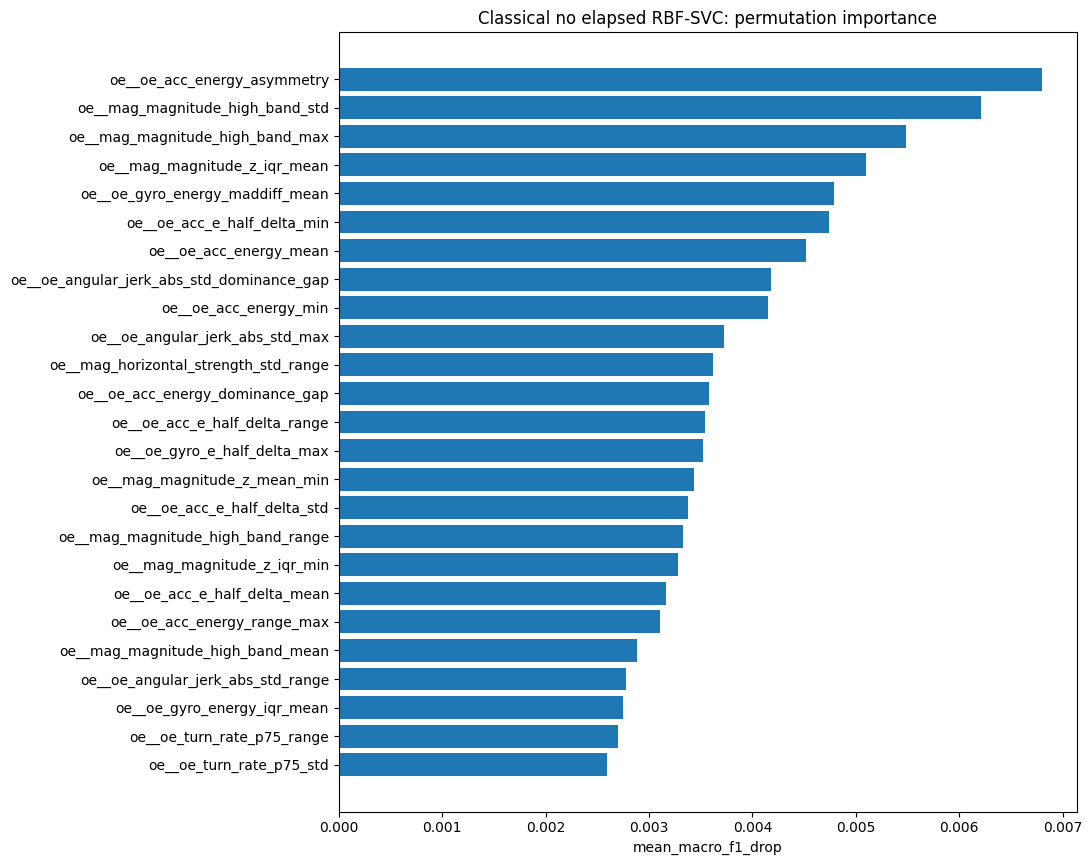

Saved plot: /content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/plot_classical_no_elapsed_rbf_permutation.png

CLASSICAL EXPLAINABILITY 2: with elapsed, best classical model = Logistic Regression, k=80


,condition,model,k,fold,test_group,n_selected_features,accuracy,macro_f1,balanced_accuracy,f1_conversation,f1_non_conversation
0,classical_with_elapsed_logreg_k80,logreg_C1,80,1,1,80,0.7615,0.7504,0.7534,0.8030,0.6977
1,classical_with_elapsed_logreg_k80,logreg_C1,80,2,2,80,0.9340,0.9119,0.9173,0.8679,0.9560
2,classical_with_elapsed_logreg_k80,logreg_C1,80,3,3,80,0.8764,0.8762,0.8766,0.8706,0.8817
3,classical_with_elapsed_logreg_k80,logreg_C1,80,4,5,80,0.8846,0.6423,0.6282,0.3478,0.9367
4,classical_with_elapsed_logreg_k80,logreg_C1,80,5,6,80,0.4268,0.3779,0.5566,0.5524,0.2034
5,classical_with_elapsed_logreg_k80,logreg_C1,80,6,7,80,0.9259,0.8289,0.7764,0.7000,0.9577
6,classical_with_elapsed_logreg_k80,logreg_C1,80,7,8,80,0.8318,0.8250,0.8211,0.7907,0.8594
7,classical_with_elapsed_logreg_k80,logreg_C1,80,8,9,80,0.7907,0.6838,0.6667,0.5000,0.8676
8,classical_with_elapsed_logreg_k80,logreg_C1,80,9,10,80,0.4571,0.3137,0.5000,0.6275,0.0000



Top permutation features, classical with elapsed:


,condition,model,k,feature,family,mean_macro_f1_drop,std_macro_f1_drop,mean_conversation_f1_drop,mean_non_conversation_f1_drop,mean_scaled_conversation,mean_scaled_non_conversation,selected_in_folds,class_mean_difference_conv_minus_nonconv,higher_values_seen_in
0,classical_with_elapsed_logreg_k80,logreg_C1,80,elapsed_min,elapsed time,0.1604,0.1028,0.2168,0.1040,-0.6811,0.0203,9,-0.7014,non_conversation
1,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_jerk_abs_mean_mean,jerk / movement change,0.0350,0.0819,0.0501,0.0199,0.5408,0.0519,9,0.4889,conversation
2,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_gyro_energy_mean,gyroscope / head turn,0.0342,0.0764,0.0433,0.0250,0.5196,-0.0014,9,0.5210,conversation
3,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_gyro_energy_std_mean,gyroscope / head turn,0.0337,0.0617,0.0478,0.0196,0.6301,0.1028,9,0.5273,conversation
4,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_active_count_atleast2_frac,acceleration / head movement,0.0259,0.0332,0.0268,0.0251,-0.3951,0.1133,9,-0.5084,non_conversation
5,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_jerk_abs_mean_asymmetry,jerk / movement change,0.0249,0.0028,0.0302,0.0195,-0.3320,-0.3441,2,0.0121,conversation
6,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_gyro_energy_range_asymmetry,gyroscope / head turn,0.0214,0.0234,0.0218,0.0210,-0.3874,-0.2415,7,-0.1459,non_conversation
7,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_energy_maddiff_mean,acceleration / head movement,0.0212,0.0493,0.0249,0.0176,0.6226,0.0787,9,0.5440,conversation
8,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_active_count_all3_frac,acceleration / head movement,0.0208,0.0121,0.0254,0.0163,0.0791,0.3044,2,-0.2253,non_conversation
9,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__mag_magnitude_z_std_mean,magnetometer / orientation,0.0205,0.0462,0.0271,0.0140,0.6474,0.0978,9,0.5496,conversation



Top coefficient features, classical with elapsed:
Positive coefficient pulls toward conversation.
Negative coefficient pulls toward non_conversation.


,condition,model,k,feature,family,mean_coef,mean_abs_coef,std_coef,mean_scaled_conversation,mean_scaled_non_conversation,selected_in_folds,pulls_toward,class_mean_difference_conv_minus_nonconv
0,classical_with_elapsed_logreg_k80,logreg_C1,80,elapsed_min,elapsed time,-3.2314,3.2314,0.2875,-0.6811,0.0203,9,non_conversation,-0.7014
1,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__mag_horizontal_strength_mean_mean,magnetometer / orientation,-1.0616,1.0616,NaN,-1.0651,-1.1615,1,non_conversation,0.0964
2,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_gyro_energy_mean,gyroscope / head turn,0.9971,0.9971,0.2562,0.5196,-0.0014,9,conversation,0.5210
3,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_angular_jerk_abs_mean_mean,jerk / movement change,-0.9451,0.9451,0.3776,0.6040,0.0759,9,non_conversation,0.5281
4,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__mag_magnitude_z_mean_mean,magnetometer / orientation,0.8650,0.9361,0.6121,0.3541,-0.0990,9,conversation,0.4531
5,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_energy_iqr_min,acceleration / head movement,-0.9335,0.9335,0.2084,0.3760,-0.0282,9,non_conversation,0.4043
6,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_active_count_atleast2_frac,acceleration / head movement,-0.8513,0.8513,0.2381,-0.3951,0.1133,9,non_conversation,-0.5084
7,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_acc_burst_rate_p75_min,acceleration / head movement,0.8232,0.8232,0.2668,0.1546,0.0753,7,conversation,0.0793
8,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__mag_magnitude_z_mean_max,magnetometer / orientation,-0.7918,0.7918,0.1498,0.0453,0.2404,5,non_conversation,-0.1951
9,classical_with_elapsed_logreg_k80,logreg_C1,80,oe__oe_gyro_active_count_mean,gyroscope / head turn,0.7598,0.7598,0.4063,0.3229,0.0941,6,conversation,0.2288


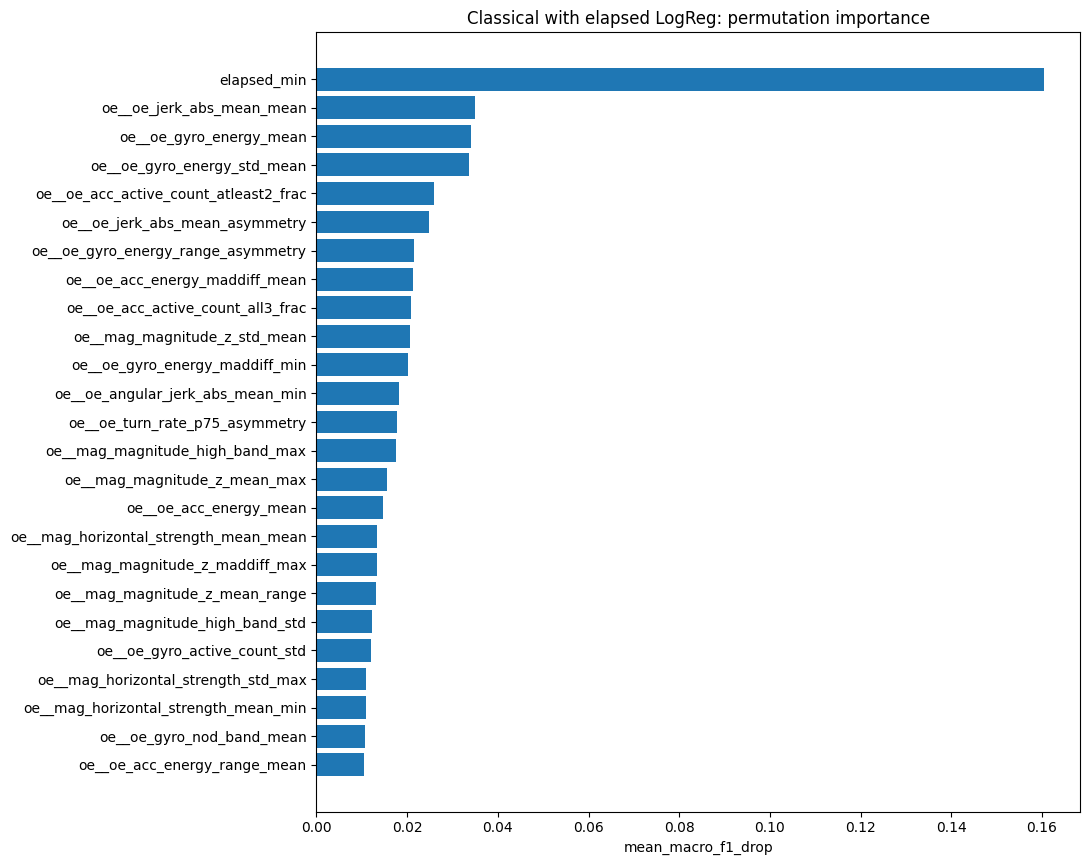

Saved plot: /content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/plot_classical_with_elapsed_logreg_permutation.png


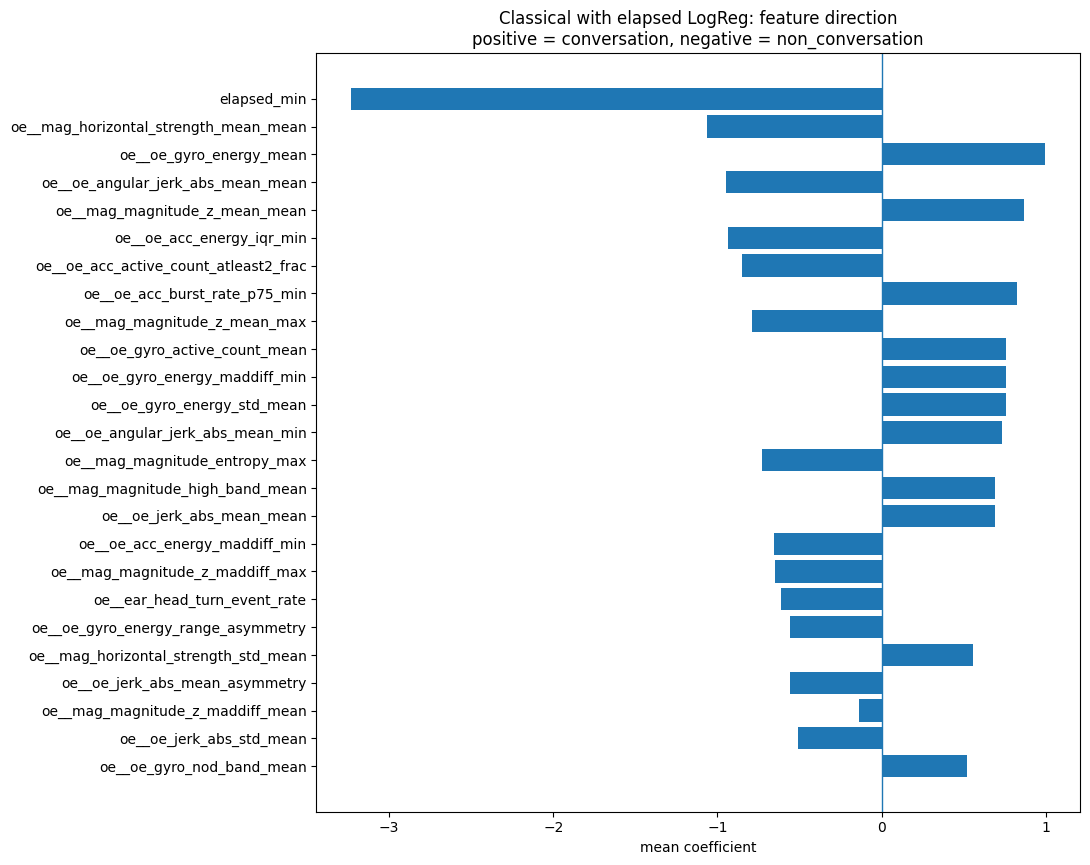

Saved plot: /content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/plot_classical_with_elapsed_logreg_coefficients.png

DL EXPLAINABILITY: best balanced model = GRU, seq_len=3, 30s context, k=200

DL explainability fold 1
Fold 1 | acc=0.5514 | macro-F1=0.4977 | conv-F1=0.3333 | nonconv-F1=0.6620

DL explainability fold 2
Fold 2 | acc=0.8558 | macro-F1=0.7534 | conv-F1=0.5946 | nonconv-F1=0.9123

DL explainability fold 3
Fold 3 | acc=0.6552 | macro-F1=0.6548 | conv-F1=0.6667 | nonconv-F1=0.6429

DL explainability fold 4
Fold 4 | acc=0.7422 | macro-F1=0.4787 | conv-F1=0.1081 | nonconv-F1=0.8493

DL explainability fold 5
Fold 5 | acc=0.2625 | macro-F1=0.2184 | conv-F1=0.4040 | nonconv-F1=0.0328

DL explainability fold 6
Fold 6 | acc=0.9062 | macro-F1=0.7321 | conv-F1=0.5161 | nonconv-F1=0.9481

DL explainability fold 7
Fold 7 | acc=0.8381 | macro-F1=0.8332 | conv-F1=0.8046 | nonconv-F1=0.8618

DL explainability fold 8
Fold 8 | acc=0.7882 | macro-F1=0.6691 | conv-F1=0.4706 | no

,fold,test_group,model,seq_len,context_seconds,k_features,n_sequences,accuracy,macro_f1,balanced_accuracy,f1_conversation,f1_non_conversation
0,1,1,gru,3,30,200,107,0.5514,0.4977,0.5610,0.3333,0.6620
1,2,2,gru,3,30,200,104,0.8558,0.7534,0.7167,0.5946,0.9123
2,3,3,gru,3,30,200,87,0.6552,0.6548,0.6622,0.6667,0.6429
3,4,5,gru,3,30,200,128,0.7422,0.4787,0.4883,0.1081,0.8493
4,5,6,gru,3,30,200,80,0.2625,0.2184,0.3798,0.4040,0.0328
5,6,7,gru,3,30,200,160,0.9062,0.7321,0.6739,0.5161,0.9481
6,7,8,gru,3,30,200,105,0.8381,0.8332,0.8292,0.8046,0.8618
7,8,9,gru,3,30,200,170,0.7882,0.6691,0.6538,0.4706,0.8676
8,9,10,gru,3,30,200,33,0.8182,0.8036,0.7951,0.7500,0.8571



Top DL sequence permutation features:


,condition,model,seq_len,context_seconds,k_features,feature,family,mean_macro_f1_drop,std_macro_f1_drop,mean_conversation_f1_drop,mean_non_conversation_f1_drop,mean_scaled_conversation,mean_scaled_non_conversation,selected_in_folds,class_mean_difference_conv_minus_nonconv,higher_values_seen_in
0,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_high_band_mean,magnetometer / orientation,0.0246,0.0615,0.0425,0.0068,0.4435,1.3067,9,-0.8633,non_conversation
1,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_high_band_range,magnetometer / orientation,0.0205,0.0497,0.0346,0.0064,0.8078,2.0841,9,-1.2763,non_conversation
2,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__oe_acc_entropy_asymmetry,acceleration / head movement,0.0176,NaN,0.0330,0.0022,-0.1982,-0.3027,1,0.1045,conversation
3,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_z_mean_min,magnetometer / orientation,0.0151,0.0390,0.0248,0.0053,0.2940,-0.2636,9,0.5575,conversation
4,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_z_mean_mean,magnetometer / orientation,0.0126,0.0237,0.0202,0.0051,0.3344,-0.1469,9,0.4812,conversation
5,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_vel_abs_std_min,magnetometer / orientation,0.0126,0.0350,0.0231,0.0021,-0.1945,-0.8434,9,0.6489,conversation
6,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__oe_gyro_energy_iqr_std,gyroscope / head turn,0.0117,NaN,0.0075,0.0159,0.2110,0.5622,1,-0.3511,non_conversation
7,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_mid_band_std,magnetometer / orientation,0.0096,NaN,0.0107,0.0085,0.2610,0.6684,1,-0.4073,non_conversation
8,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__mag_magnitude_vel_abs_mean_mean,magnetometer / orientation,0.0093,0.0208,0.0153,0.0034,0.1584,-0.2906,9,0.4490,conversation
9,dl_no_elapsed_gru_seq3_k200,gru,3,30,200,oe__oe_acc_burst_rate_p75_dominance_gap,acceleration / head movement,0.0092,NaN,0.0091,0.0094,0.4090,0.2433,1,0.1657,conversation


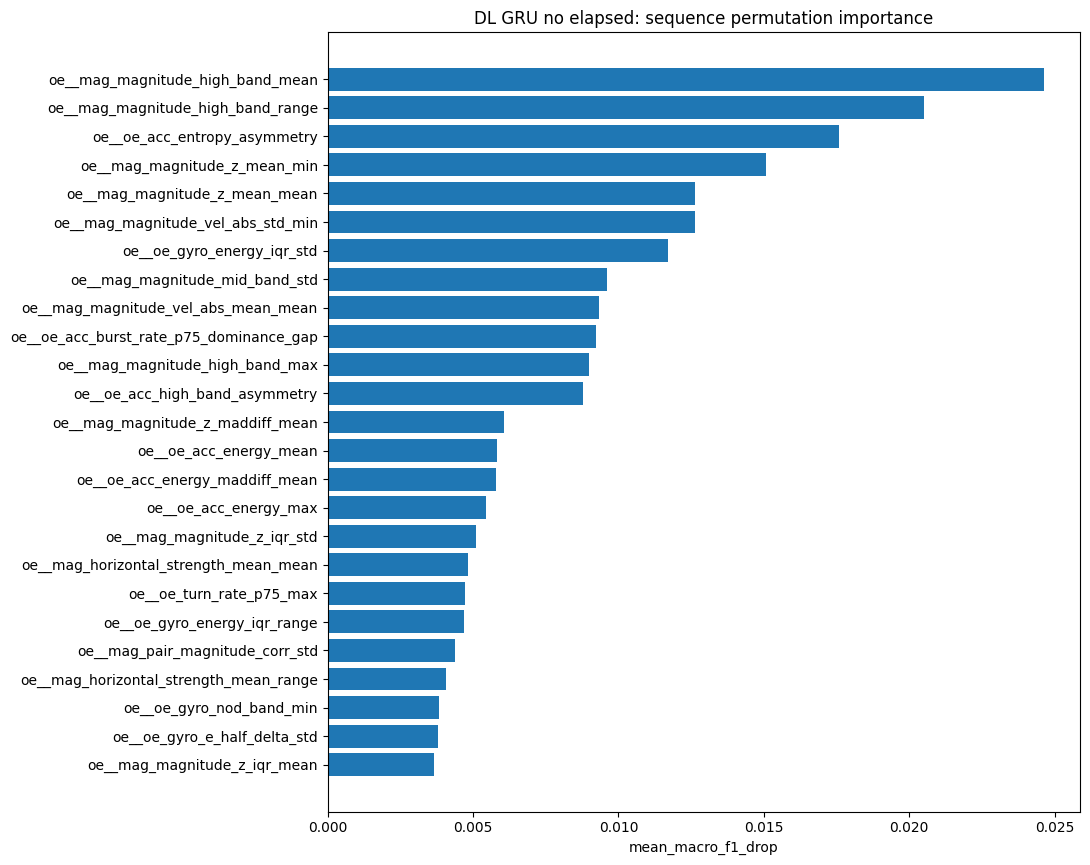

Saved plot: /content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION/plot_dl_gru_seq3_k200_permutation.png

FEATURE FAMILY SUMMARIES

Classical no elapsed, RBF-SVC, family-level importance:


,family,total_macro_f1_drop,mean_macro_f1_drop,n_features
0,acceleration / head movement,0.0606,0.0006,98
5,magnetometer / orientation,0.0271,0.0003,80
4,jerk / movement change,0.0118,0.0004,28
3,head gesture,0.0116,0.0011,11
1,dominance / asymmetry,-0.0004,-0.0001,4
2,gyroscope / head turn,-0.0099,-0.0001,84



Classical with elapsed, LogReg, family-level importance:


,family,total_macro_f1_drop,mean_macro_f1_drop,n_features
3,gyroscope / head turn,0.1778,0.0061,29
2,elapsed time,0.1604,0.1604,1
0,acceleration / head movement,0.1288,0.0050,26
5,jerk / movement change,0.0841,0.0070,12
6,magnetometer / orientation,0.0792,0.0023,35
4,head gesture,0.0234,0.0033,7
1,dominance / asymmetry,0.0218,0.0109,2



DL GRU no elapsed, family-level importance:


,family,total_macro_f1_drop,mean_macro_f1_drop,n_features
5,magnetometer / orientation,0.0393,0.0006,71
1,dominance / asymmetry,-0.0029,-0.0007,4
3,head gesture,-0.0150,-0.0014,11
4,jerk / movement change,-0.0169,-0.0009,19
2,gyroscope / head turn,-0.1872,-0.0026,73
0,acceleration / head movement,-0.3163,-0.0038,84



Saved explainability outputs to:
/content/drive/MyDrive/thesis/data/OE_CONVERSATION_NONCONVERSATION


In [17]:
# ================================================================
# OE CONVERSATION vs NON-CONVERSATION EXPLAINABILITY
# Classical permutation + coefficients + DL sequence permutation
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

# ------------------------------------------------
# Safety checks
# ------------------------------------------------

required_vars = [
    "df", "oe_features", "TARGET_COL", "GROUP_COL",
    "START_COL", "END_COL", "POS_LABEL", "NEG_LABEL", "OUT_DIR"
]

missing = [v for v in required_vars if v not in globals()]
if len(missing) > 0:
    raise RuntimeError(f"Missing variables from previous notebook cells: {missing}")

os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_SEED = 42
N_REPEATS_CLASSICAL = 5
N_REPEATS_DL = 3

# For fast testing, set DO_DL_EXPLAIN = False
DO_CLASSICAL_EXPLAIN = True
DO_DL_EXPLAIN = True

# Positive class for classical explanation:
# 1 = conversation, 0 = non_conversation
y_classical = (df[TARGET_COL].values == POS_LABEL).astype(int)
groups = df[GROUP_COL].values

print("Class mapping for classical explanation:")
print("1 =", POS_LABEL)
print("0 =", NEG_LABEL)


# ------------------------------------------------
# Helper functions
# ------------------------------------------------

def feature_family(feature):
    f = str(feature).lower()

    if "elapsed" in f:
        return "elapsed time"
    if "mag" in f:
        return "magnetometer / orientation"
    if "gyro" in f or "gyr" in f:
        return "gyroscope / head turn"
    if "acc" in f:
        return "acceleration / head movement"
    if "pitch" in f or "roll" in f:
        return "head posture"
    if "jerk" in f:
        return "jerk / movement change"
    if "sync" in f or "corr" in f or "lag" in f:
        return "cross-person synchrony"
    if "active" in f or "burst" in f:
        return "activity / burst"
    if "asym" in f or "dominance" in f:
        return "dominance / asymmetry"
    if "turn" in f or "nod" in f:
        return "head gesture"
    return "other OE feature"


def class_f1s(y_true, y_pred, conv_label=1):
    """
    For classical:
    labels [1, 0] means:
    index 0 = conversation
    index 1 = non_conversation
    """
    f1_each = f1_score(
        y_true,
        y_pred,
        labels=[1, 0],
        average=None,
        zero_division=0
    )
    return f1_each[0], f1_each[1]


def plot_top_bar(df_plot, value_col, title, out_path, top_n=25):
    if df_plot is None or len(df_plot) == 0:
        print("Nothing to plot:", title)
        return

    temp = df_plot.head(top_n).copy()
    temp = temp.iloc[::-1]

    plt.figure(figsize=(11, max(5, 0.35 * len(temp))))
    plt.barh(temp["feature"], temp[value_col])
    plt.xlabel(value_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved plot:", out_path)


def make_classical_model(model_key):
    if model_key == "rbfSVC_C1_gscale":
        return SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=42,
        )

    if model_key == "logreg_C1":
        return LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42,
        )

    raise ValueError(f"Unknown model_key: {model_key}")


# ------------------------------------------------
# Classical LOGO permutation + coefficient explanation
# ------------------------------------------------

def explain_classical_logo(
    model_key,
    feature_list,
    k,
    include_elapsed,
    condition_name,
    n_repeats=5,
    random_seed=42
):
    """
    Produces:
    1. permutation importance:
       How much macro-F1 drops when a feature is shuffled.
    2. coefficient direction, only for Logistic Regression:
       Positive coefficient means pulls toward conversation.
       Negative coefficient means pulls toward non_conversation.
    """

    rng = np.random.default_rng(random_seed)
    logo = LeaveOneGroupOut()

    feats = list(feature_list)
    if include_elapsed and "elapsed_min" not in feats:
        feats = feats + ["elapsed_min"]

    X_raw = df[feats].apply(pd.to_numeric, errors="coerce").values
    y = y_classical.copy()

    perm_rows = []
    coef_rows = []
    fold_summary_rows = []

    for fold, (tr_idx, te_idx) in enumerate(logo.split(X_raw, y, groups), start=1):
        test_group = groups[te_idx][0]

        Xtr_raw = X_raw[tr_idx]
        Xte_raw = X_raw[te_idx]
        ytr = y[tr_idx]
        yte = y[te_idx]

        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(Xtr_raw)
        Xte = imputer.transform(Xte_raw)

        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        if k == "all":
            Xtr_sel = Xtr
            Xte_sel = Xte
            selected_names = feats
        else:
            actual_k = min(int(k), Xtr.shape[1])
            selector = SelectKBest(f_classif, k=actual_k)
            Xtr_sel = selector.fit_transform(Xtr, ytr)
            Xte_sel = selector.transform(Xte)
            selected_names = [feats[i] for i in selector.get_support(indices=True)]

        model = make_classical_model(model_key)
        model.fit(Xtr_sel, ytr)

        base_pred = model.predict(Xte_sel)
        base_acc = accuracy_score(yte, base_pred)
        base_macro = f1_score(yte, base_pred, average="macro", zero_division=0)
        base_bal = balanced_accuracy_score(yte, base_pred)
        base_f1_conv, base_f1_nonconv = class_f1s(yte, base_pred)

        fold_summary_rows.append({
            "condition": condition_name,
            "model": model_key,
            "k": k,
            "fold": fold,
            "test_group": test_group,
            "n_selected_features": len(selected_names),
            "accuracy": base_acc,
            "macro_f1": base_macro,
            "balanced_accuracy": base_bal,
            "f1_conversation": base_f1_conv,
            "f1_non_conversation": base_f1_nonconv,
        })

        # Coefficients: only meaningful for Logistic Regression
        if hasattr(model, "coef_"):
            coefs = model.coef_[0]

            for j, feat in enumerate(selected_names):
                coef = float(coefs[j])

                direction = POS_LABEL if coef > 0 else NEG_LABEL

                conv_mean = np.nanmean(Xte_sel[yte == 1, j]) if np.any(yte == 1) else np.nan
                nonconv_mean = np.nanmean(Xte_sel[yte == 0, j]) if np.any(yte == 0) else np.nan

                coef_rows.append({
                    "condition": condition_name,
                    "model": model_key,
                    "k": k,
                    "fold": fold,
                    "test_group": test_group,
                    "feature": feat,
                    "family": feature_family(feat),
                    "coef": coef,
                    "abs_coef": abs(coef),
                    "pulls_toward": direction,
                    "mean_scaled_conversation": conv_mean,
                    "mean_scaled_non_conversation": nonconv_mean,
                    "class_mean_difference_conv_minus_nonconv": conv_mean - nonconv_mean,
                })

        # Permutation importance
        for j, feat in enumerate(selected_names):
            macro_scores = []
            conv_f1_scores = []
            nonconv_f1_scores = []

            for rep in range(n_repeats):
                Xp = Xte_sel.copy()
                Xp[:, j] = Xp[rng.permutation(len(Xp)), j]

                pred_p = model.predict(Xp)
                macro_scores.append(f1_score(yte, pred_p, average="macro", zero_division=0))

                f1c, f1n = class_f1s(yte, pred_p)
                conv_f1_scores.append(f1c)
                nonconv_f1_scores.append(f1n)

            conv_mean = np.nanmean(Xte_sel[yte == 1, j]) if np.any(yte == 1) else np.nan
            nonconv_mean = np.nanmean(Xte_sel[yte == 0, j]) if np.any(yte == 0) else np.nan

            higher_in = POS_LABEL if conv_mean > nonconv_mean else NEG_LABEL

            perm_rows.append({
                "condition": condition_name,
                "model": model_key,
                "k": k,
                "fold": fold,
                "test_group": test_group,
                "feature": feat,
                "family": feature_family(feat),
                "baseline_macro_f1": base_macro,
                "permuted_macro_f1_mean": float(np.mean(macro_scores)),
                "macro_f1_drop": float(base_macro - np.mean(macro_scores)),
                "baseline_f1_conversation": base_f1_conv,
                "permuted_f1_conversation_mean": float(np.mean(conv_f1_scores)),
                "conversation_f1_drop": float(base_f1_conv - np.mean(conv_f1_scores)),
                "baseline_f1_non_conversation": base_f1_nonconv,
                "permuted_f1_non_conversation_mean": float(np.mean(nonconv_f1_scores)),
                "non_conversation_f1_drop": float(base_f1_nonconv - np.mean(nonconv_f1_scores)),
                "mean_scaled_conversation": conv_mean,
                "mean_scaled_non_conversation": nonconv_mean,
                "higher_values_seen_in": higher_in,
            })

    perm_df = pd.DataFrame(perm_rows)
    coef_df = pd.DataFrame(coef_rows)
    fold_df = pd.DataFrame(fold_summary_rows)

    perm_summary = (
        perm_df
        .groupby(["condition", "model", "k", "feature", "family"], as_index=False)
        .agg(
            mean_macro_f1_drop=("macro_f1_drop", "mean"),
            std_macro_f1_drop=("macro_f1_drop", "std"),
            mean_conversation_f1_drop=("conversation_f1_drop", "mean"),
            mean_non_conversation_f1_drop=("non_conversation_f1_drop", "mean"),
            mean_scaled_conversation=("mean_scaled_conversation", "mean"),
            mean_scaled_non_conversation=("mean_scaled_non_conversation", "mean"),
            selected_in_folds=("fold", "nunique"),
        )
    )

    perm_summary["class_mean_difference_conv_minus_nonconv"] = (
        perm_summary["mean_scaled_conversation"] -
        perm_summary["mean_scaled_non_conversation"]
    )

    perm_summary["higher_values_seen_in"] = np.where(
        perm_summary["class_mean_difference_conv_minus_nonconv"] > 0,
        POS_LABEL,
        NEG_LABEL,
    )

    perm_summary = perm_summary.sort_values(
        ["mean_macro_f1_drop", "mean_conversation_f1_drop"],
        ascending=False
    ).reset_index(drop=True)

    if len(coef_df) > 0:
        coef_summary = (
            coef_df
            .groupby(["condition", "model", "k", "feature", "family"], as_index=False)
            .agg(
                mean_coef=("coef", "mean"),
                mean_abs_coef=("abs_coef", "mean"),
                std_coef=("coef", "std"),
                mean_scaled_conversation=("mean_scaled_conversation", "mean"),
                mean_scaled_non_conversation=("mean_scaled_non_conversation", "mean"),
                selected_in_folds=("fold", "nunique"),
            )
        )

        coef_summary["pulls_toward"] = np.where(
            coef_summary["mean_coef"] > 0,
            POS_LABEL,
            NEG_LABEL,
        )

        coef_summary["class_mean_difference_conv_minus_nonconv"] = (
            coef_summary["mean_scaled_conversation"] -
            coef_summary["mean_scaled_non_conversation"]
        )

        coef_summary = coef_summary.sort_values(
            "mean_abs_coef",
            ascending=False
        ).reset_index(drop=True)
    else:
        coef_summary = pd.DataFrame()

    return fold_df, perm_summary, coef_summary


# ------------------------------------------------
# Run classical explainability
# ------------------------------------------------

if DO_CLASSICAL_EXPLAIN:

    print("\n" + "=" * 100)
    print("CLASSICAL EXPLAINABILITY 1: no elapsed, best classical model = RBF-SVC, all OE features")
    print("=" * 100)

    classical_no_fold, classical_no_perm, classical_no_coef = explain_classical_logo(
        model_key="rbfSVC_C1_gscale",
        feature_list=oe_features,
        k="all",
        include_elapsed=False,
        condition_name="classical_no_elapsed_rbf_all",
        n_repeats=N_REPEATS_CLASSICAL,
    )

    display(classical_no_fold.round(4))
    print("\nTop permutation features, classical no elapsed:")
    display(classical_no_perm.head(30).round(4))

    classical_no_perm.to_csv(
        f"{OUT_DIR}/explain_classical_no_elapsed_rbf_all_permutation.csv",
        index=False
    )

    plot_top_bar(
        classical_no_perm,
        "mean_macro_f1_drop",
        "Classical no elapsed RBF-SVC: permutation importance",
        f"{OUT_DIR}/plot_classical_no_elapsed_rbf_permutation.png",
        top_n=25,
    )


    print("\n" + "=" * 100)
    print("CLASSICAL EXPLAINABILITY 2: with elapsed, best classical model = Logistic Regression, k=80")
    print("=" * 100)

    classical_elapsed_fold, classical_elapsed_perm, classical_elapsed_coef = explain_classical_logo(
        model_key="logreg_C1",
        feature_list=oe_features,
        k=80,
        include_elapsed=True,
        condition_name="classical_with_elapsed_logreg_k80",
        n_repeats=N_REPEATS_CLASSICAL,
    )

    display(classical_elapsed_fold.round(4))

    print("\nTop permutation features, classical with elapsed:")
    display(classical_elapsed_perm.head(30).round(4))

    print("\nTop coefficient features, classical with elapsed:")
    print("Positive coefficient pulls toward conversation.")
    print("Negative coefficient pulls toward non_conversation.")
    display(classical_elapsed_coef.head(30).round(4))

    classical_elapsed_perm.to_csv(
        f"{OUT_DIR}/explain_classical_with_elapsed_logreg_k80_permutation.csv",
        index=False
    )

    classical_elapsed_coef.to_csv(
        f"{OUT_DIR}/explain_classical_with_elapsed_logreg_k80_coefficients.csv",
        index=False
    )

    plot_top_bar(
        classical_elapsed_perm,
        "mean_macro_f1_drop",
        "Classical with elapsed LogReg: permutation importance",
        f"{OUT_DIR}/plot_classical_with_elapsed_logreg_permutation.png",
        top_n=25,
    )

    # Coefficient plot: signed direction
    temp = classical_elapsed_coef.head(25).copy().iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.35 * len(temp))))
    plt.barh(temp["feature"], temp["mean_coef"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("mean coefficient")
    plt.title("Classical with elapsed LogReg: feature direction\npositive = conversation, negative = non_conversation")
    plt.tight_layout()
    coef_plot_path = f"{OUT_DIR}/plot_classical_with_elapsed_logreg_coefficients.png"
    plt.savefig(coef_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved plot:", coef_plot_path)


# ------------------------------------------------
# DL explainability: best balanced DL model
# GRU, seq_len=3, 30s context, k=200, no elapsed
# ------------------------------------------------

def torch_predict(model, X_seq, batch_size=512):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_seq), batch_size):
            xb = torch.tensor(X_seq[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            preds.extend(logits.argmax(1).cpu().numpy())

    return np.array(preds)


def explain_dl_gru_logo(
    seq_len=3,
    k_features=200,
    n_repeats=3,
    random_seed=42
):
    """
    Re-trains the best balanced DL model:
    GRU, seq_len=3, k=200, OE only, no elapsed.

    Then it computes sequence-level permutation importance:
    for each selected feature, the whole feature trajectory is shuffled
    across test sequences.

    For DL label coding:
    0 = conversation
    1 = non_conversation
    """

    needed = ["make_sequences", "build_model", "make_loader", "set_seed"]

    missing = [x for x in needed if x not in globals()]
    if len(missing) > 0:
        raise RuntimeError(
            "The DL helper functions are missing. Run the DL model-definition cells first. "
            f"Missing: {missing}"
        )

    choose_validation_group_fn = globals().get("choose_validation_group", None)

    if choose_validation_group_fn is None:
        def choose_validation_group_fn(train_groups):
            return np.sort(train_groups)[-1]

    if "MAX_EPOCHS" not in globals():
        globals()["MAX_EPOCHS"] = 80
    if "PATIENCE" not in globals():
        globals()["PATIENCE"] = 12
    if "BATCH_SIZE" not in globals():
        globals()["BATCH_SIZE"] = 64

    rng = np.random.default_rng(random_seed)

    label_to_id = {POS_LABEL: 0, NEG_LABEL: 1}
    y_all = df[TARGET_COL].map(label_to_id).astype(int).values
    groups_all = df[GROUP_COL].values
    starts_all = pd.to_numeric(df[START_COL], errors="coerce").values

    feature_list = oe_features.copy()
    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    model_cfg = {
        "model_type": "gru",
        "hidden_dim": 64,
        "num_layers": 1,
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    }

    logo = LeaveOneGroupOut()

    fold_rows = []
    perm_rows = []

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):
        print(f"\nDL explainability fold {fold}")

        set_seed(random_seed + fold)

        test_group = groups_all[te_idx][0]
        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(X_raw[tr_idx])
        Xval = imputer.transform(X_raw[val_idx])
        Xte = imputer.transform(X_raw[te_idx])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(int(k_features), Xtr.shape[1])
        selector = SelectKBest(f_classif, k=actual_k)

        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        selected_names = [feature_list[i] for i in selector.get_support(indices=True)]

        X_fold = np.zeros((len(X_raw), actual_k), dtype=np.float32)
        X_fold[tr_idx] = Xtr
        X_fold[val_idx] = Xval
        X_fold[te_idx] = Xte

        Xtr_seq, ytr_seq, _, _ = make_sequences(
            X_fold[tr_idx],
            y_all[tr_idx],
            groups_all[tr_idx],
            starts_all[tr_idx],
            seq_len
        )

        Xval_seq, yval_seq, _, _ = make_sequences(
            X_fold[val_idx],
            y_all[val_idx],
            groups_all[val_idx],
            starts_all[val_idx],
            seq_len
        )

        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            X_fold[te_idx],
            y_all[te_idx],
            groups_all[te_idx],
            starts_all[te_idx],
            seq_len
        )

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            print("Skipping fold because not enough sequences.")
            continue

        model = build_model(model_cfg, input_dim=actual_k).to(DEVICE)

        opt = torch.optim.AdamW(
            model.parameters(),
            lr=model_cfg["lr"],
            weight_decay=model_cfg["weight_decay"]
        )

        loss_fn = torch.nn.CrossEntropyLoss()

        train_loader = make_loader(Xtr_seq, ytr_seq, BATCH_SIZE, shuffle=True)
        val_loader = make_loader(Xval_seq, yval_seq, BATCH_SIZE, shuffle=False)

        best_state = None
        best_val_macro = -1
        patience_left = PATIENCE

        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()

            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            val_pred = torch_predict(model, Xval_seq)
            val_macro = f1_score(yval_seq, val_pred, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_left = PATIENCE
            else:
                patience_left -= 1

            if patience_left <= 0:
                break

        model.load_state_dict(best_state)
        model.to(DEVICE)

        base_pred = torch_predict(model, Xte_seq)

        base_acc = accuracy_score(yte_seq, base_pred)
        base_macro = f1_score(yte_seq, base_pred, average="macro", zero_division=0)
        base_bal = balanced_accuracy_score(yte_seq, base_pred)

        f1_each = f1_score(
            yte_seq,
            base_pred,
            labels=[0, 1],
            average=None,
            zero_division=0
        )

        base_f1_conv = f1_each[0]
        base_f1_nonconv = f1_each[1]

        fold_rows.append({
            "fold": fold,
            "test_group": test_group,
            "model": "gru",
            "seq_len": seq_len,
            "context_seconds": seq_len * 10,
            "k_features": actual_k,
            "n_sequences": len(Xte_seq),
            "accuracy": base_acc,
            "macro_f1": base_macro,
            "balanced_accuracy": base_bal,
            "f1_conversation": base_f1_conv,
            "f1_non_conversation": base_f1_nonconv,
        })

        print(
            f"Fold {fold} | acc={base_acc:.4f} | "
            f"macro-F1={base_macro:.4f} | "
            f"conv-F1={base_f1_conv:.4f} | "
            f"nonconv-F1={base_f1_nonconv:.4f}"
        )

        # Sequence-level permutation:
        # shuffle the full time trajectory of one feature across test sequences.
        for j, feat in enumerate(selected_names):
            macro_scores = []
            conv_f1_scores = []
            nonconv_f1_scores = []

            for rep in range(n_repeats):
                Xp = Xte_seq.copy()
                perm_idx = rng.permutation(len(Xp))

                # Preserve temporal shape within a sequence,
                # but assign that feature trajectory to another sequence.
                Xp[:, :, j] = Xp[perm_idx, :, j]

                pred_p = torch_predict(model, Xp)

                macro_scores.append(
                    f1_score(yte_seq, pred_p, average="macro", zero_division=0)
                )

                f1_p = f1_score(
                    yte_seq,
                    pred_p,
                    labels=[0, 1],
                    average=None,
                    zero_division=0
                )

                conv_f1_scores.append(f1_p[0])
                nonconv_f1_scores.append(f1_p[1])

            conv_mean = np.nanmean(Xte_seq[yte_seq == 0, :, j]) if np.any(yte_seq == 0) else np.nan
            nonconv_mean = np.nanmean(Xte_seq[yte_seq == 1, :, j]) if np.any(yte_seq == 1) else np.nan

            higher_in = POS_LABEL if conv_mean > nonconv_mean else NEG_LABEL

            perm_rows.append({
                "condition": "dl_no_elapsed_gru_seq3_k200",
                "model": "gru",
                "seq_len": seq_len,
                "context_seconds": seq_len * 10,
                "k_features": actual_k,
                "fold": fold,
                "test_group": test_group,
                "feature": feat,
                "family": feature_family(feat),
                "baseline_macro_f1": base_macro,
                "permuted_macro_f1_mean": float(np.mean(macro_scores)),
                "macro_f1_drop": float(base_macro - np.mean(macro_scores)),
                "baseline_f1_conversation": base_f1_conv,
                "permuted_f1_conversation_mean": float(np.mean(conv_f1_scores)),
                "conversation_f1_drop": float(base_f1_conv - np.mean(conv_f1_scores)),
                "baseline_f1_non_conversation": base_f1_nonconv,
                "permuted_f1_non_conversation_mean": float(np.mean(nonconv_f1_scores)),
                "non_conversation_f1_drop": float(base_f1_nonconv - np.mean(nonconv_f1_scores)),
                "mean_scaled_conversation": conv_mean,
                "mean_scaled_non_conversation": nonconv_mean,
                "higher_values_seen_in": higher_in,
            })

    fold_df = pd.DataFrame(fold_rows)
    perm_df = pd.DataFrame(perm_rows)

    perm_summary = (
        perm_df
        .groupby(["condition", "model", "seq_len", "context_seconds", "k_features", "feature", "family"], as_index=False)
        .agg(
            mean_macro_f1_drop=("macro_f1_drop", "mean"),
            std_macro_f1_drop=("macro_f1_drop", "std"),
            mean_conversation_f1_drop=("conversation_f1_drop", "mean"),
            mean_non_conversation_f1_drop=("non_conversation_f1_drop", "mean"),
            mean_scaled_conversation=("mean_scaled_conversation", "mean"),
            mean_scaled_non_conversation=("mean_scaled_non_conversation", "mean"),
            selected_in_folds=("fold", "nunique"),
        )
    )

    perm_summary["class_mean_difference_conv_minus_nonconv"] = (
        perm_summary["mean_scaled_conversation"] -
        perm_summary["mean_scaled_non_conversation"]
    )

    perm_summary["higher_values_seen_in"] = np.where(
        perm_summary["class_mean_difference_conv_minus_nonconv"] > 0,
        POS_LABEL,
        NEG_LABEL,
    )

    perm_summary = perm_summary.sort_values(
        ["mean_macro_f1_drop", "mean_conversation_f1_drop"],
        ascending=False
    ).reset_index(drop=True)

    return fold_df, perm_summary


# ------------------------------------------------
# Run DL explainability
# ------------------------------------------------

if DO_DL_EXPLAIN:

    print("\n" + "=" * 100)
    print("DL EXPLAINABILITY: best balanced model = GRU, seq_len=3, 30s context, k=200")
    print("=" * 100)

    dl_fold_explain, dl_perm_summary = explain_dl_gru_logo(
        seq_len=3,
        k_features=200,
        n_repeats=N_REPEATS_DL,
        random_seed=42
    )

    print("\nDL fold-level performance during explainability retraining:")
    display(dl_fold_explain.round(4))

    print("\nTop DL sequence permutation features:")
    display(dl_perm_summary.head(40).round(4))

    dl_fold_explain.to_csv(
        f"{OUT_DIR}/explain_dl_gru_seq3_k200_fold_performance.csv",
        index=False
    )

    dl_perm_summary.to_csv(
        f"{OUT_DIR}/explain_dl_gru_seq3_k200_sequence_permutation.csv",
        index=False
    )

    plot_top_bar(
        dl_perm_summary,
        "mean_macro_f1_drop",
        "DL GRU no elapsed: sequence permutation importance",
        f"{OUT_DIR}/plot_dl_gru_seq3_k200_permutation.png",
        top_n=25,
    )


# ------------------------------------------------
# Compact family-level summaries
# ------------------------------------------------

print("\n" + "=" * 100)
print("FEATURE FAMILY SUMMARIES")
print("=" * 100)

if DO_CLASSICAL_EXPLAIN:
    print("\nClassical no elapsed, RBF-SVC, family-level importance:")
    classical_no_family = (
        classical_no_perm
        .groupby("family", as_index=False)
        .agg(
            total_macro_f1_drop=("mean_macro_f1_drop", "sum"),
            mean_macro_f1_drop=("mean_macro_f1_drop", "mean"),
            n_features=("feature", "count"),
        )
        .sort_values("total_macro_f1_drop", ascending=False)
    )
    display(classical_no_family.round(4))
    classical_no_family.to_csv(
        f"{OUT_DIR}/explain_classical_no_elapsed_family_summary.csv",
        index=False
    )

    print("\nClassical with elapsed, LogReg, family-level importance:")
    classical_elapsed_family = (
        classical_elapsed_perm
        .groupby("family", as_index=False)
        .agg(
            total_macro_f1_drop=("mean_macro_f1_drop", "sum"),
            mean_macro_f1_drop=("mean_macro_f1_drop", "mean"),
            n_features=("feature", "count"),
        )
        .sort_values("total_macro_f1_drop", ascending=False)
    )
    display(classical_elapsed_family.round(4))
    classical_elapsed_family.to_csv(
        f"{OUT_DIR}/explain_classical_with_elapsed_family_summary.csv",
        index=False
    )

if DO_DL_EXPLAIN:
    print("\nDL GRU no elapsed, family-level importance:")
    dl_family = (
        dl_perm_summary
        .groupby("family", as_index=False)
        .agg(
            total_macro_f1_drop=("mean_macro_f1_drop", "sum"),
            mean_macro_f1_drop=("mean_macro_f1_drop", "mean"),
            n_features=("feature", "count"),
        )
        .sort_values("total_macro_f1_drop", ascending=False)
    )
    display(dl_family.round(4))
    dl_family.to_csv(
        f"{OUT_DIR}/explain_dl_gru_seq3_k200_family_summary.csv",
        index=False
    )

print("\nSaved explainability outputs to:")
print(OUT_DIR)